In [40]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [41]:
end = datetime.now()
end

datetime.datetime(2026, 1, 14, 16, 28, 41, 577653)

In [42]:
start_date= datetime(end.year -1, end.month , end.day)
start_date

datetime.datetime(2025, 1, 14, 0, 0)

In [43]:
stock_list=['AXISBANK.NS', 'ICICIBANK.NS','KOTAKBANK.NS','HDFCBANK.NS']

In [44]:
name_stock=[]
name_df=[]

for stock_symbol in stock_list:
    df = yf.download(stock_symbol, start=start_date, end=end, progress=False)  # Download data for the current stock

    df.reset_index(inplace=True)  # Reset index

    stock_name = stock_symbol.split('.')[0]  # Extract stock name from symbol
    name_stock.append(stock_name)

    df['Company'] = stock_name    # Add a column for Company with the stock name

    df_name = f"{stock_name.lower()}_df"  # Define DataFrame name dynamically using the stock name
    name_df.append(df_name)

    globals()[df_name] = df  # Assign the DataFrame to the dynamically created name

In [45]:
name_df

['axisbank_df', 'icicibank_df', 'kotakbank_df', 'hdfcbank_df']

In [46]:
name_stock

['AXISBANK', 'ICICIBANK', 'KOTAKBANK', 'HDFCBANK']

In [47]:
df = globals()[name_df[0]]
print(df.columns)


MultiIndex([(   'Date',            ''),
            (  'Close', 'AXISBANK.NS'),
            (   'High', 'AXISBANK.NS'),
            (    'Low', 'AXISBANK.NS'),
            (   'Open', 'AXISBANK.NS'),
            ( 'Volume', 'AXISBANK.NS'),
            ('Company',            '')],
           names=['Price', 'Ticker'])


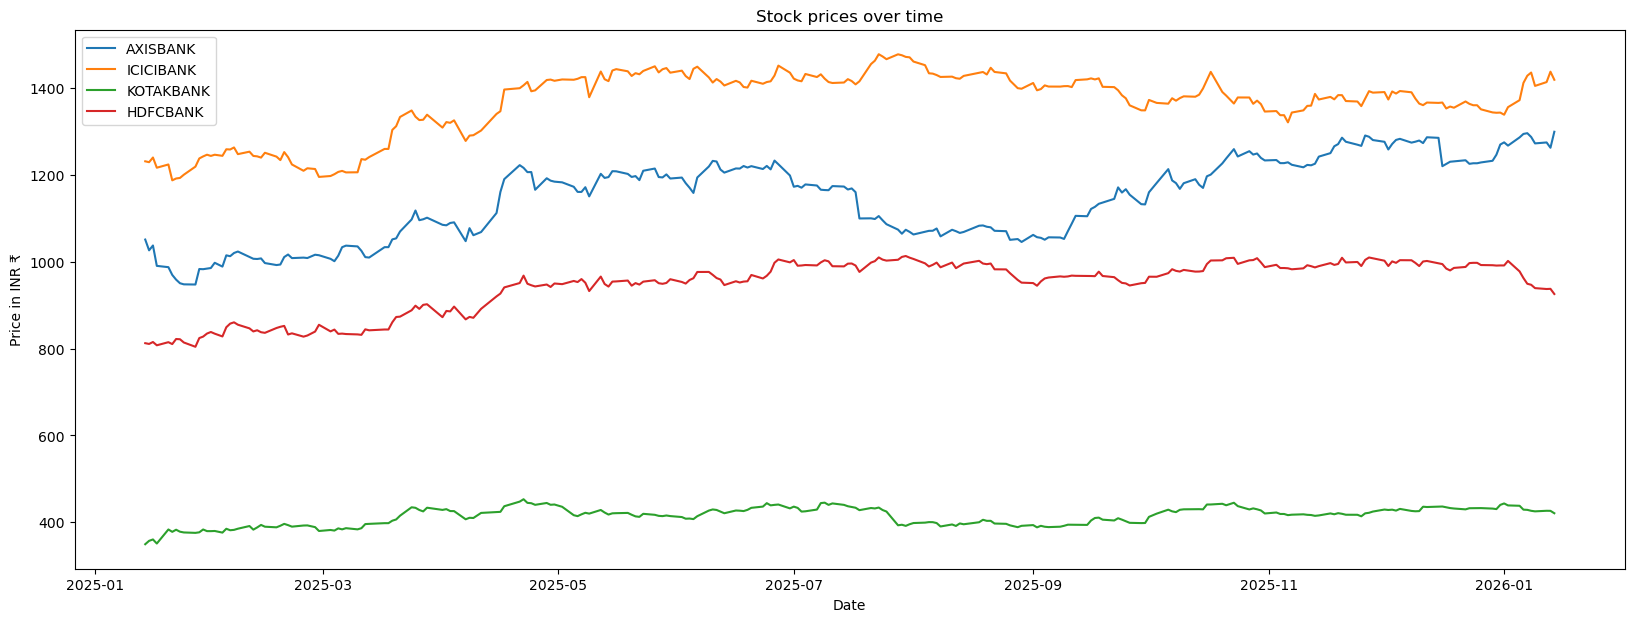

In [48]:
plt.figure(figsize=(20, 7))
for df_name, stock_name in zip(name_df, name_stock):
    df = globals()[df_name]
    price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
    plt.plot(df['Date'], df[price_col], label=stock_name)

# Adding labels and legend
plt.xlabel('Date')
plt.ylabel("Price in INR ₹")
plt.title("Stock prices over time")
plt.legend()
plt.show()

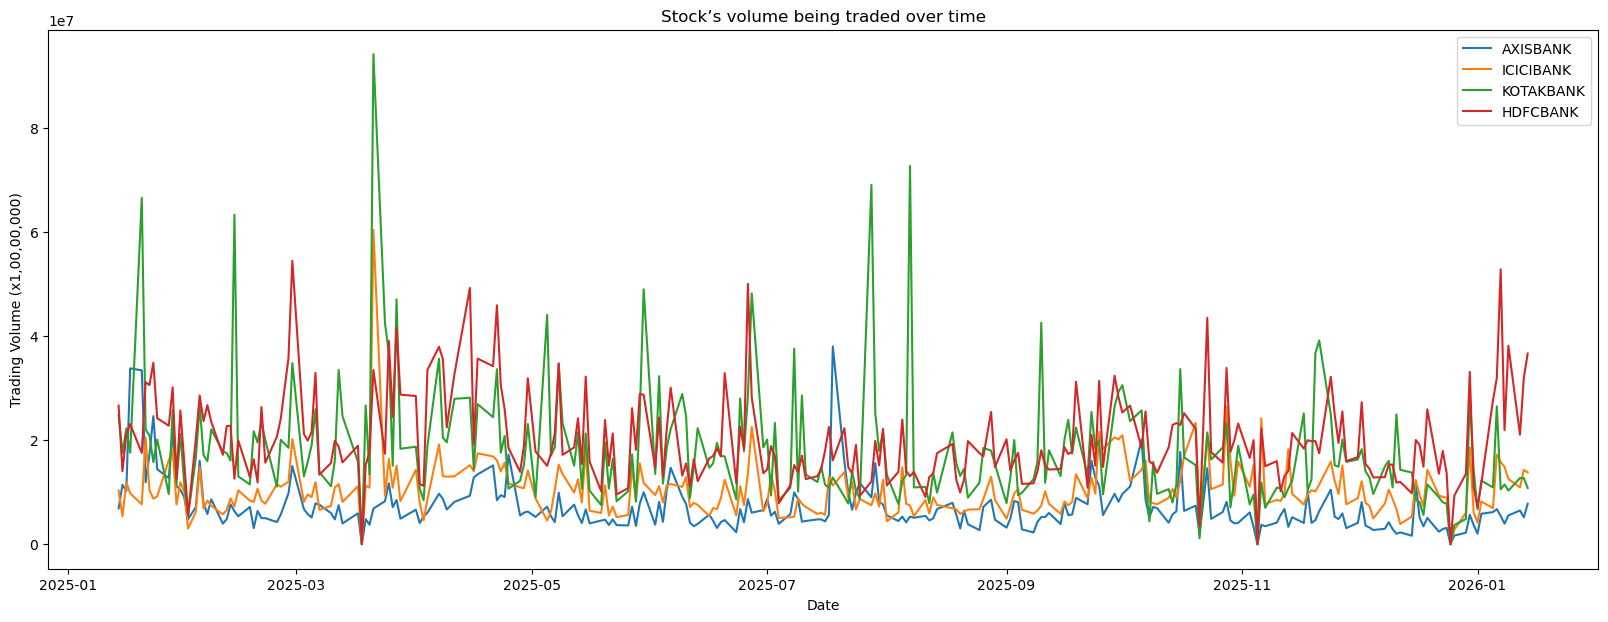

In [49]:
plt.figure(figsize=(20, 7))
for df_name, stock_name in zip(name_df, name_stock):
    df = globals()[df_name]
    plt.plot(df['Date'], df['Volume'], label=stock_name)

# Adding labels and legend
plt.xlabel('Date')
plt.ylabel("Trading Volume (x1,00,00,000)")
plt.title("Stock’s volume being traded over time")
plt.legend()
plt.show()

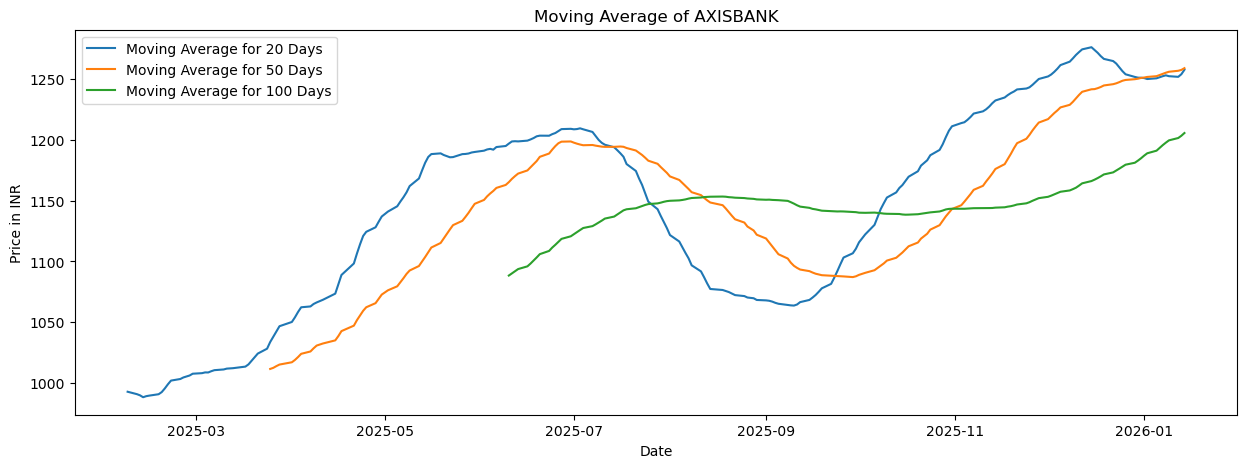

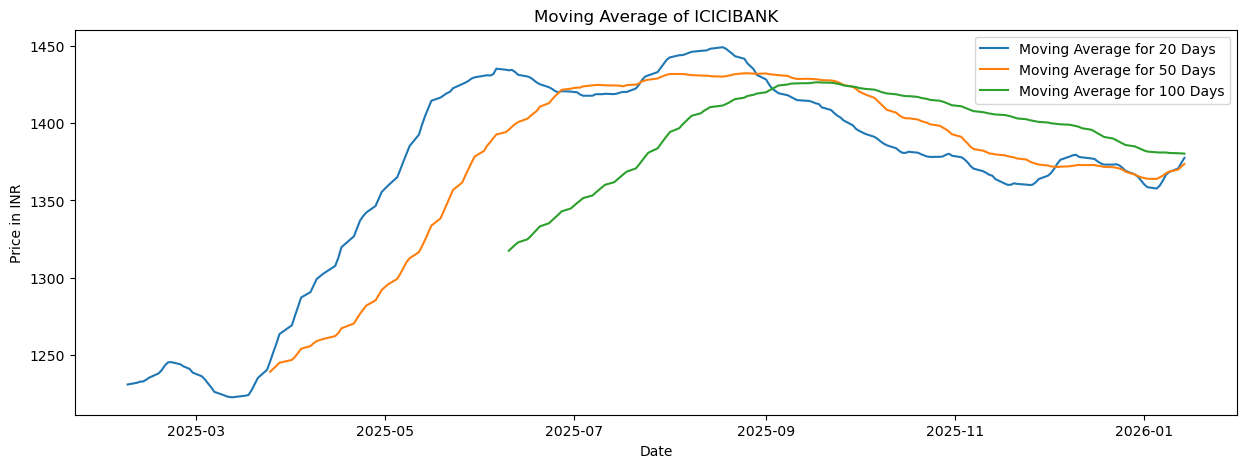

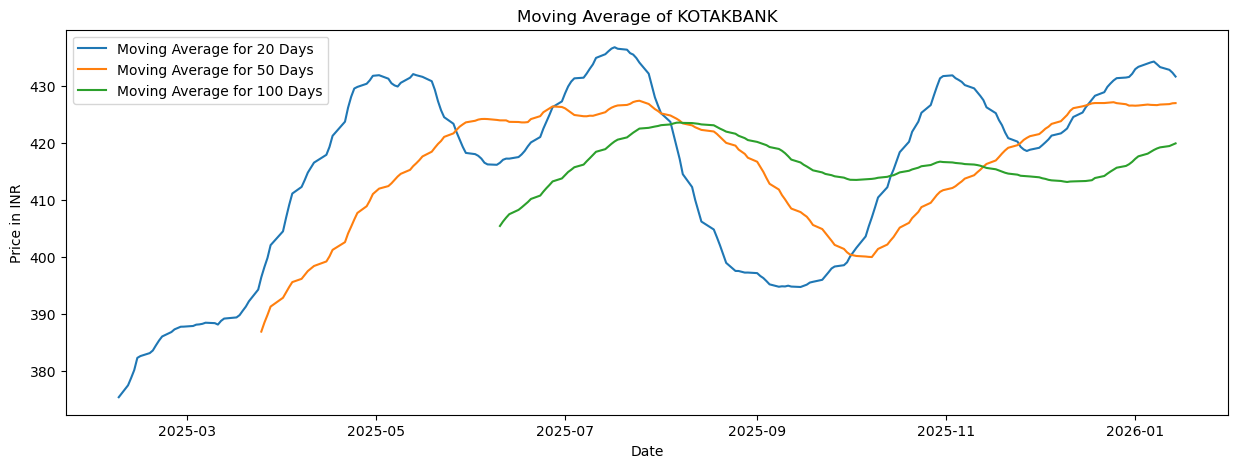

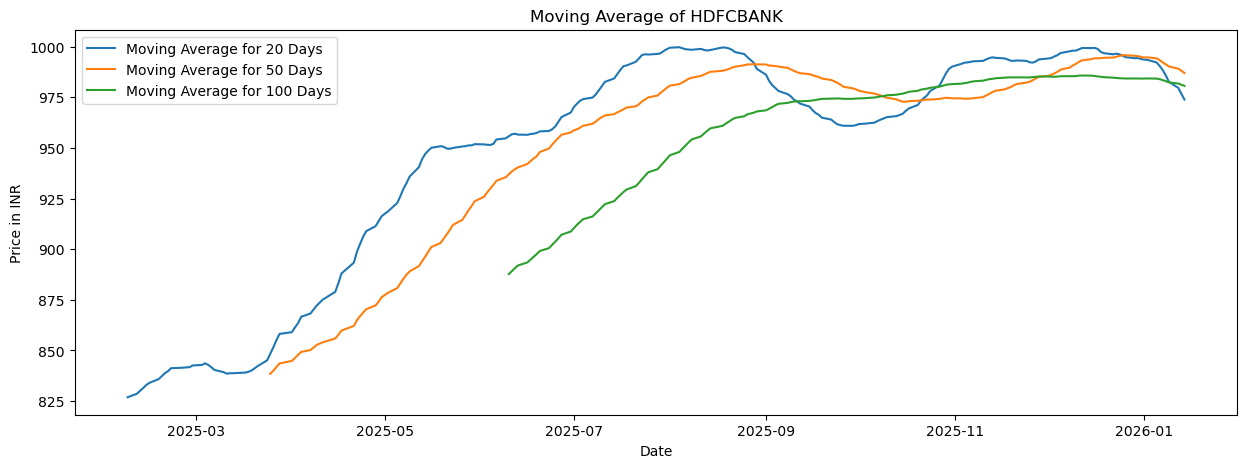

In [50]:
for df_name, stock_name in zip(name_df, name_stock):
    df = globals()[df_name]  # Access DataFrame by name
    df['MA for 20 Days'] = df['Close'].rolling(20).mean()
    df['MA for 50 Days'] = df['Close'].rolling(50).mean()
    df['MA for 100 Days'] = df['Close'].rolling(100).mean()

    plt.figure(figsize=(15, 5))
    plt.plot(df['Date'], df['MA for 20 Days'], label="Moving Average for 20 Days")
    plt.plot(df['Date'], df['MA for 50 Days'], label="Moving Average for 50 Days")
    plt.plot(df['Date'], df['MA for 100 Days'], label="Moving Average for 100 Days")
    plt.xlabel("Date")
    plt.ylabel("Price in INR")
    plt.title(f"Moving Average of {stock_name}")
    plt.legend()
    plt.show()

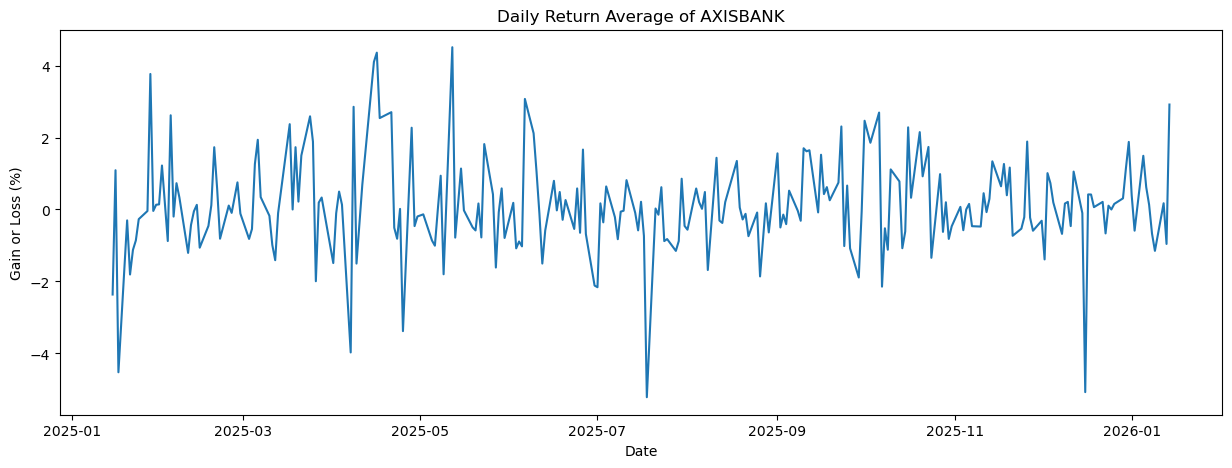

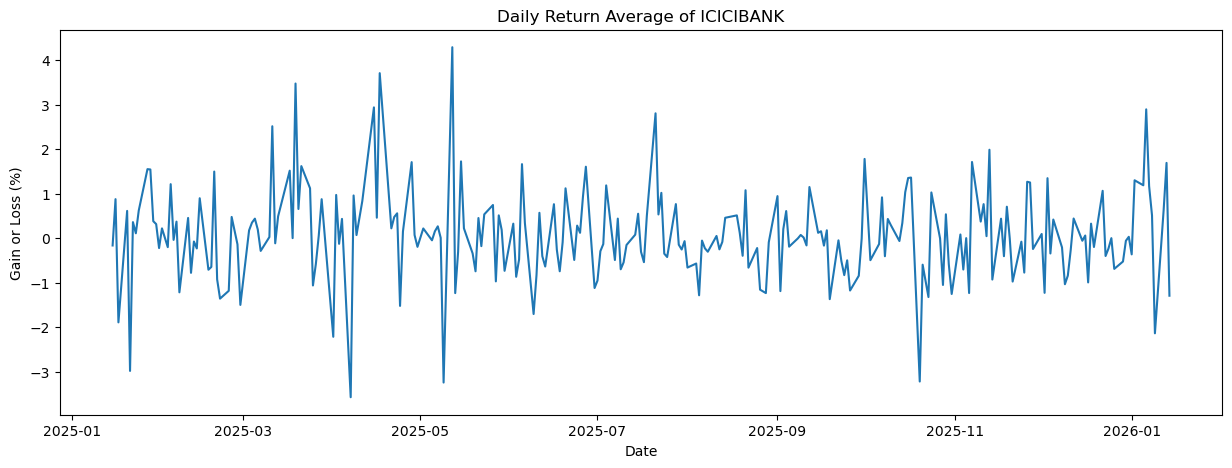

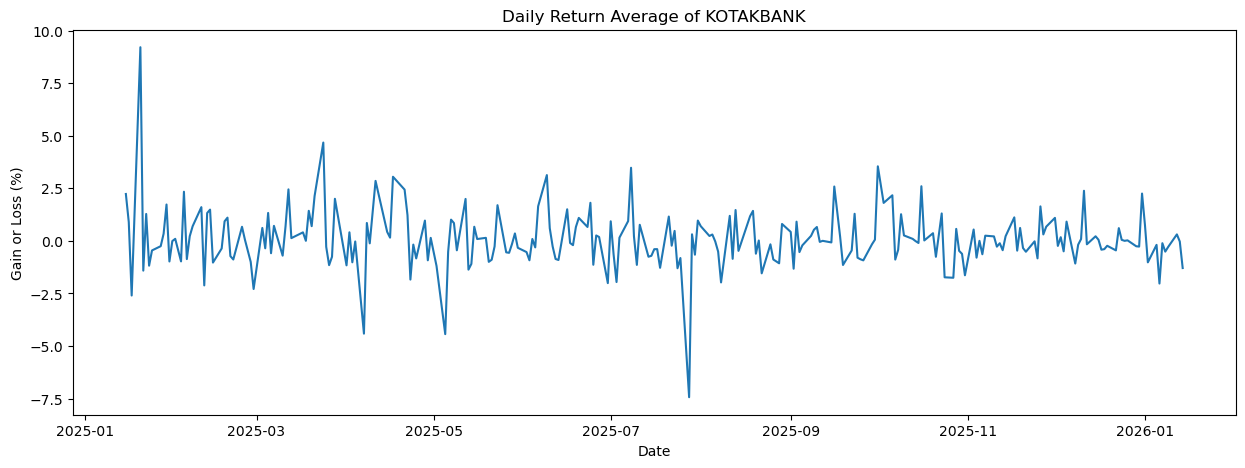

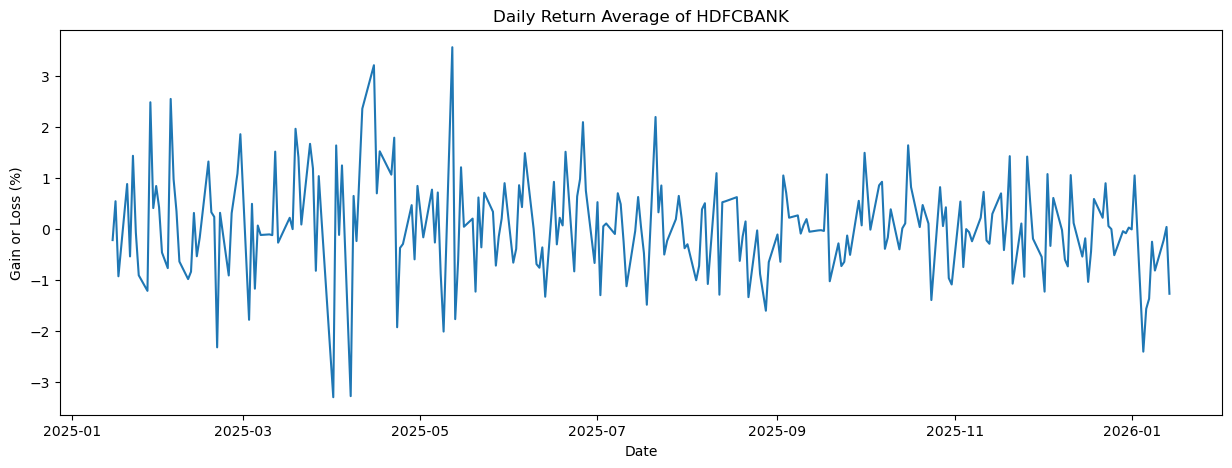

In [51]:
for df_name, stock_name in zip(name_df, name_stock):
    df = globals()[df_name]  # Access DataFrame by name
    df['Daily Return %'] = df['Close'].pct_change()* 100
    plt.figure(figsize=(15, 5))
    plt.plot(df['Date'],df['Daily Return %'])
    plt.xlabel("Date")
    plt.ylabel("Gain or Loss (%)")
    plt.title(f"Daily Return Average of {stock_name}")
    #plt.legend()
    plt.show()

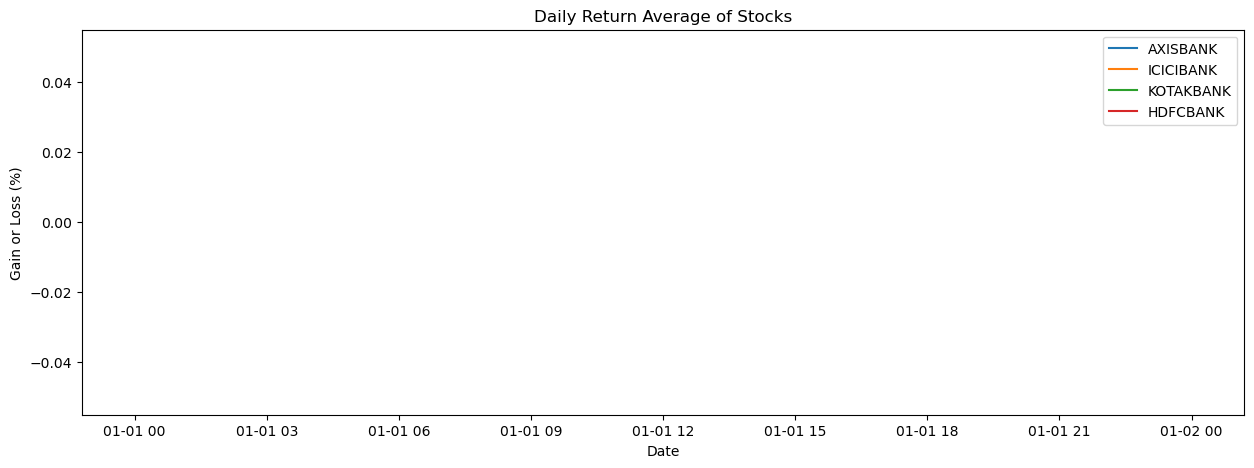

In [62]:
plt.figure(figsize=(15, 5))
for df_name, stock_name in zip(name_df, name_stock):
    df = globals()[df_name]  # Access DataFrame by name
    df['Daily Return %'] = df['Close'].pct_change() * 100
    plt.plot(df['Date'],df['Daily Return %'],label=stock_name)

plt.xlabel("Date")
plt.ylabel("Gain or Loss (%)")
plt.title("Daily Return Average of Stocks")
plt.legend()
plt.show()

In [63]:
print(df[['Date','Close','Daily Return %']].head())


Price        Date       Close Daily Return %
Ticker            HDFCBANK.NS               
0      2025-01-14  812.319885            NaN
1      2025-01-15  810.568604            NaN
2      2025-01-16  815.008606            NaN
3      2025-01-17  807.460571            NaN
4      2025-01-20  814.613892            NaN


In [64]:
def trend(x):
  if x > -1.5 and x <= 1.5:
    return 'Slight or No change'
  elif x > 1.5 and x <= 4:
    return 'Slight Positive'
  elif x < -1.5 and x >= -4:
    return 'Slight Negative'
  elif x > 4 and x <= 6:
    return 'Positive'
  elif x < -4 and x >= -6:
    return 'Negative'
  elif x > 6 and x <= 7:
    return 'Among top gainers'
  elif x < -6 and x >= -7:
    return 'Among top losers'
  elif x > 7:
    return 'Bull run'
  elif x <= -7:
    return 'Bear drop'

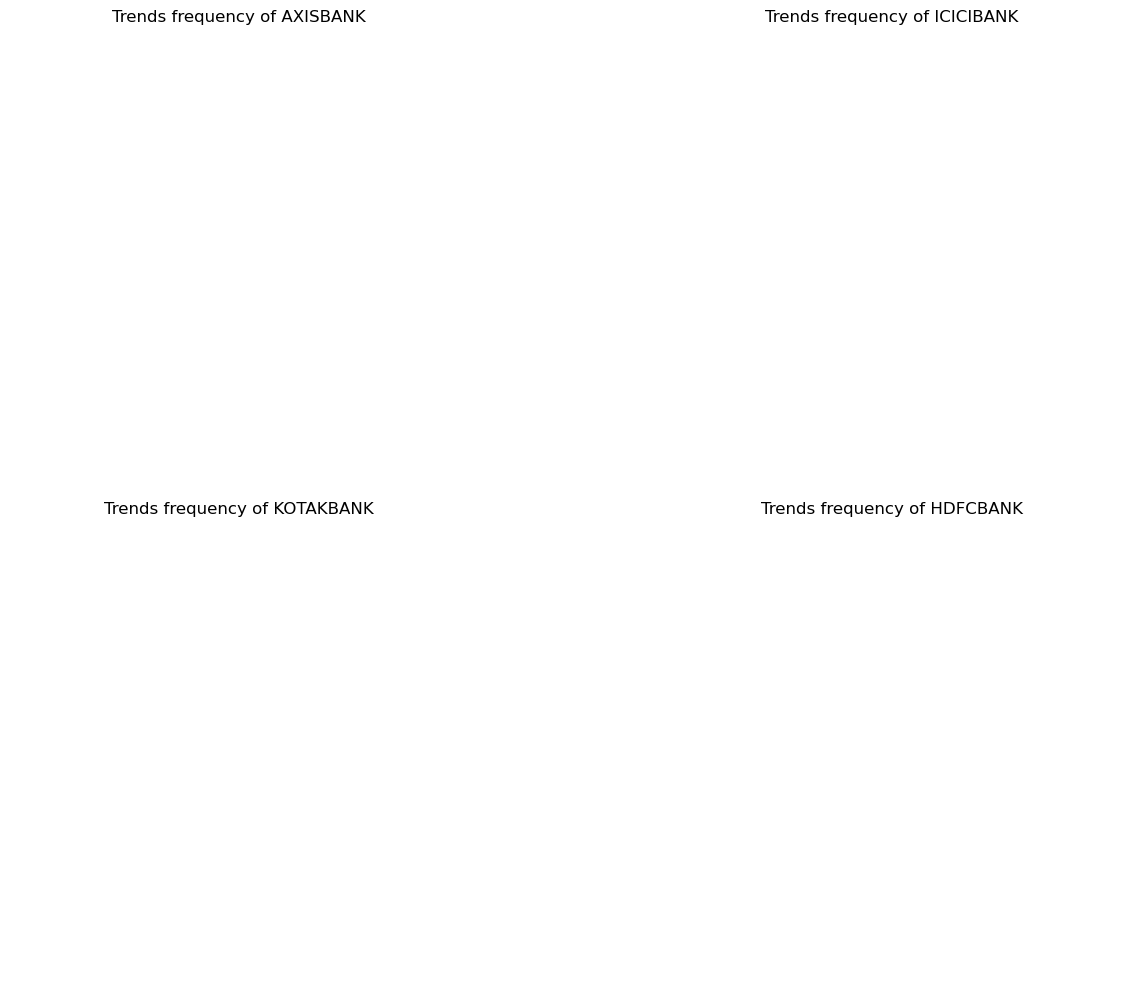

In [68]:
# Initialize the figure and subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Iterate through each DataFrame and plot the pie chart on respective subplot
for i, (df_name, stock_name) in enumerate(zip(name_df, name_stock)):
    df = globals()[df_name]  # Access DataFrame by name
    df['Trend'] = df['Daily Return %'].apply(lambda x: trend(x))
    trendpie = df['Trend'].value_counts()

    # Calculate the row and column index for subplot
    row_index = i // 2
    col_index = i % 2

    # Plot the pie chart on respective subplot
    axes[row_index, col_index].pie(trendpie.values, labels=trendpie.index, autopct='%1.2f%%')
    axes[row_index, col_index].set_title(f"Trends frequency of {stock_name}")

# Adjust layout
plt.tight_layout()
plt.show()

In [66]:
# Create a DataFrame from selected columns of each DataFrame using name_df and name_stock
df = pd.DataFrame({stock_name: globals()[df_name]['Close'] for df_name, stock_name in zip(name_df, name_stock)})

ValueError: If using all scalar values, you must pass an index

In [67]:
df.head()

Price,Date,Close,High,Low,Open,Volume,Company,MA for 20 Days,MA for 50 Days,MA for 100 Days,Daily Return %,Trend
Ticker,,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,,,,,,
0,2025-01-14,812.319885,817.055857,807.583913,809.014587,26661432,HDFCBANK,NaN,NaN,NaN,NaN,None
1,2025-01-15,810.568604,820.262522,807.238615,817.203890,14022892,HDFCBANK,NaN,NaN,NaN,NaN,None
2,2025-01-16,815.008606,819.201925,810.469918,815.403235,21212454,HDFCBANK,NaN,NaN,NaN,NaN,None
3,2025-01-17,807.460571,814.243881,803.390585,810.790560,23112076,HDFCBANK,NaN,NaN,NaN,NaN,None
4,2025-01-20,814.613892,819.399185,802.157267,802.157267,17557618,HDFCBANK,NaN,NaN,NaN,NaN,None


In [59]:
df.corr()

ValueError: could not convert string to float: 'HDFCBANK'

In [39]:
sns.heatmap(df.corr())
plt.show()

ValueError: could not convert string to float: 'HDFCBANK'